# Salary Prediction using Simple Linear Regression

**Business Question:** Can we predict an employee's Salary based on their Years of Experience?

This follows the same simple linear regression workflow covered in class (Study Hours → Scores),
applied here to a new dataset: Years of Experience → Salary.

**Steps:**
1. Data Preparation (load, inspect, clean, visualize)
2. Model Training
3. Model Evaluation
4. Conclusion (equation, coefficient interpretation)


## Step 1: Data Preparation

In [ ]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
d = pd.read_excel("Salary.xlsx")
d.head(3)

   YearsExperience  Salary
0              1.1   10000
1              1.3   10500
2              1.5   11000

We have two columns:
- `YearsExperience` → independent variable / feature (X)
- `Salary` → dependent variable / target (y)


In [ ]:
d.describe()

       YearsExperience         Salary
count        86.000000      86.000000
mean          17.096124  104790.116279
std           10.623181   57680.123097
min            1.100000   10000.000000
25%            7.300000   65485.500000
50%           16.658333  106694.000000
75%           26.220833  153274.000000
max           35.783333  199854.000000

In [ ]:
# Check for missing values before modelling
d.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

No missing values — data is clean, no imputation needed.

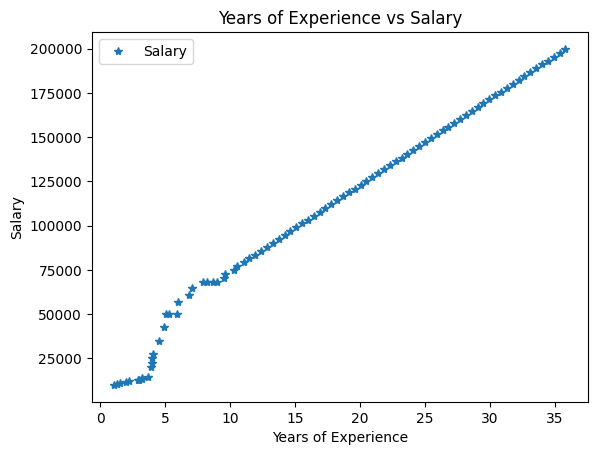

In [ ]:
# Visualizing the relationship
d.plot(x='YearsExperience', y='Salary', style='*')
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

The scatter plot shows a clear upward trend — as experience increases, salary increases. This supports using a **linear** model.

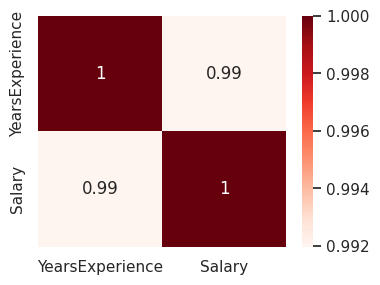

                 YearsExperience    Salary
YearsExperience         1.000000  0.991971
Salary                  0.991971  1.000000

In [ ]:
# Correlation coefficient
sns.set()
plt.figure(figsize=(4,3))
cor = d.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()
cor

Correlation between YearsExperience and Salary is **0.99**, i.e. a very strong positive linear relationship — confirms linear regression is a good fit here.

### Preparing Features (X) and Target (y)

Splitting data into `X` (feature) and `y` (target), same way as done in class.

In [ ]:
X = d.iloc[:, :-1].values   # Feature: YearsExperience
y = d.iloc[:, 1].values     # Target: Salary

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print("Train size:", len(X_train), "  Test size:", len(X_test))

Train size: 68   Test size: 18


## Step 2: Model Training

In [ ]:
from sklearn.linear_model import LinearRegression

Salary_Pred = LinearRegression()
Salary_Pred.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept (b0):", Salary_Pred.intercept_)   # Value of Salary when Experience = 0
print("Coefficient (b1):", Salary_Pred.coef_)

Intercept (b0): 13330.391275873102
Coefficient (b1): [5353.56946714]


**Regression Equation:**

Salary = b0 + b1 (YearsExperience)

Salary = 13330.39 + 5353.57 (YearsExperience)


## Step 3: Model Evaluation

In [ ]:
y_pred = Salary_Pred.predict(X_test)
r = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
r

    Actual      Predicted
0    11000   21360.745477
1    27500   35280.026091
2   129710  127807.551715
3   103406   98898.276592
4   175742  178398.783179
5    79294   72398.107730
6   112174  108534.701633
7   107790  103716.489113
8   138478  137443.976756
9   199854  204898.952042
10   13500   30461.813571
11   70526   64189.301214
12   85870   79625.426511
13  149438  149489.508057
14   14000   30461.813571
15   50000   40633.595558
16   68334   59906.445640
17  136286  135034.870495

In [ ]:
from sklearn.metrics import r2_score
from sklearn import metrics

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

R2 Score: 0.9796911035457284
Mean Absolute Error: 6277.6055016728615
Mean Squared Error: 61163741.465803474
Root Mean Squared Error: 7820.725124040831


**Interpreting the evaluation metrics:**
- **R² = 0.98** → about 98% of the variation in Salary is explained by Years of Experience. Very strong fit.
- **RMSE ≈ 7820** → on average, predictions are off by about ₹7,820, which is small relative to the salary range in the data.


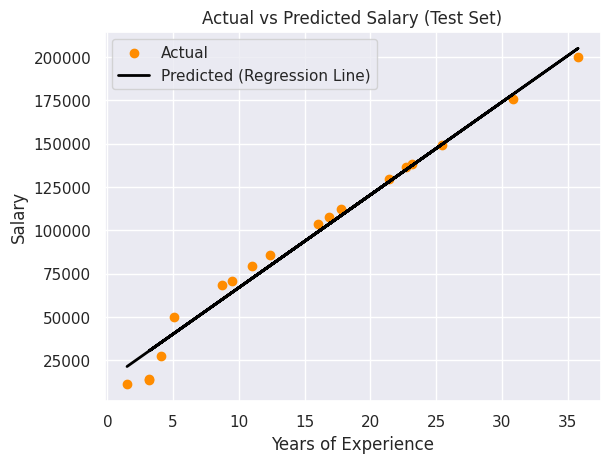

In [ ]:
plt.scatter(X_test, y_test, color='darkorange', label='Actual')
plt.plot(X_test, y_pred, color='black', linewidth=2, label='Predicted (Regression Line)')
plt.title('Actual vs Predicted Salary (Test Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

## Step 4: Conclusion

**Final Regression Equation:**

> Salary = 13330.39 + 5353.57 × (YearsExperience)

**Coefficient interpretation:** The coefficient (b1 = 5353.57) tells us that for every **one additional year of experience**, predicted salary increases by approximately **₹5,353.57**, holding everything else constant. The positive sign confirms the relationship is positive — more experience, higher predicted salary.

**Intercept interpretation:** The intercept (b0 = 13330.39) is the model's predicted salary at zero years of experience — the theoretical starting baseline salary.

**Overall:** With R² = 0.98 and a strong correlation of 0.99, Years of Experience is a very strong single predictor of Salary in this dataset, and the linear regression model fits the data well. Since one feature already explains 98% of the variance, adding more predictors is unlikely to meaningfully improve this specific model — but in a real-world setting, other factors (education, role, location, company size) would typically also be considered.
